<a href="https://colab.research.google.com/github/fathimathulaifa/ICT-assessments-and-assignments/blob/main/Assignment_on_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
data = pd.read_csv('/content/House_Pricing.csv')

In [3]:
# Display first 5 rows
data.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [4]:
data.info() # Basic info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [5]:
data.describe() # summary statistics

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Duplicate Removal**
* **Rows**: Check for duplicate rows in the dataset, if any, and remove them.
* **Columns**: Identify and drop duplicate columns, if any, based on their values.

In [6]:
data.isnull().sum() # Check missing values

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [7]:
#Dropping 'ID' as it is a unique identifier with no predictive value
data = data.drop('ID', axis=1)




In [8]:
# No of Times Visited hasIt has 19,489 missing values.
#so we gonna drop no of times visited column too
data = data.drop('No of Times Visited', axis=1)

In [9]:
data.isnull().sum()


,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [10]:
# Converted the date column to datetime format, extracted meaningful features (Sale Year and Sale Month)

data['Date House was Sold'] = pd.to_datetime(data['Date House was Sold'])

In [11]:
data['Sale Year'] = data['Date House was Sold'].dt.year


In [12]:
data['Sale Month'] = data['Date House was Sold'].dt.month

In [13]:
# dropped the original date column as raw datetime values are not directly usable in machine learning models.
data = data.drop('Date House was Sold', axis=1,errors = "ignore")

**Handling Missing Values**
  * Identify missing values in each column.
  * Handle missing values:
      1.  For **numerical columns**, use imputation techniques like mean/median   imputation.
      2. For **categorical columns**, fill with mode.

In [14]:
# Checking missing values in each column
data.isnull().sum()


,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0
Area of the House from Basement (in Sqft),3


In [15]:
# Sale Price is the target variable
# so it is better to drop those rows instead of filling them

data = data.dropna(subset=['Sale Price'])


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Sale Price                                 21609 non-null  float64
 1   No of Bedrooms                             21609 non-null  int64  
 2   No of Bathrooms                            21605 non-null  float64
 3   Flat Area (in Sqft)                        21600 non-null  float64
 4   Lot Area (in Sqft)                         21600 non-null  float64
 5   No of Floors                               21609 non-null  float64
 6   Waterfront View                            21609 non-null  object 
 7   Condition of the House                     21609 non-null  object 
 8   Overall Grade                              21609 non-null  int64  
 9   Area of the House from Basement (in Sqft)  21606 non-null  float64
 10  Basement Area (in Sqft)    

In [17]:
# Filling missing values in numerical columns using median imputation

numerical_cols = [
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Zipcode',
    'Latitude',
    'Longitude',
    'Living Area after Renovation (in Sqft)'
]

for col in numerical_cols:
    data[col] = data[col].fillna(data[col].median())


In [18]:
data.isnull().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0
Area of the House from Basement (in Sqft),0


* Checked the dataset for missing values using isnull().sum()

* Since Sale Price is the target variable, rows containing missing values in this column were removed to avoid affecting model training.


*  Missing values in numerical features (No of Bathrooms, Flat Area, Lot Area, Area of the House from Basement, Zipcode, Latitude, Longitude, and Living Area after Renovation) were replaced using the median of each column. Median imputation was chosen because it reduces the impact of outliers.

* After imputation, the dataset contains no missing values.

**Scaling Numerical Variables**

* Identify all numerical columns (excluding the target variable SalePrice).
* Scale these features using techniques like Min-Max scaling or Standard scaling.

In [19]:
X = data.drop('Sale Price', axis=1) #Features
y = data['Sale Price']  #Target

In [20]:
numerical_cols = X.select_dtypes(include=['number']).columns

print(numerical_cols)


Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)', 'Sale Year', 'Sale Month'],
      dtype='object')


In [21]:
# Apply Scaling -> StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])


In [22]:
X.head()


,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale Year,Sale Month
0,-0.398724,-1.447526,-0.979905,-0.228291,-0.915389,No,Fair,-0.563993,-0.734722,-0.658697,0.544734,-0.210149,1.870134,-0.352576,-0.306226,-0.943307,-0.260741,0.690603,1.099462
1,-0.398724,0.175684,0.533718,-0.189858,0.936817,No,Fair,-0.563993,0.460990,0.245134,0.680915,4.746219,0.879570,1.161645,-0.746479,-0.432664,-0.187900,0.690603,1.741464
2,-1.474115,-1.447526,-1.426369,-0.123276,-0.915389,No,Fair,-1.468566,-1.229916,-0.658697,1.293731,-0.210149,-0.933349,1.283619,-0.135806,1.070082,-0.172409,-1.448010,-1.468548
3,0.676667,1.149611,-0.130534,-0.243983,-0.915389,No,Excellent,-0.563993,-0.891735,1.397518,0.204281,-0.210149,1.085159,-0.283288,-1.271941,-0.914127,-0.284546,0.690603,1.741464
4,-0.398724,-0.148958,-0.435436,-0.169628,-0.915389,No,Fair,0.340581,-0.130827,-0.658697,-0.544715,-0.210149,-0.073614,0.409587,1.199152,-0.272177,-0.192880,-1.448010,-1.468548


**Encoding Categorical Variables**
* Identify all categorical columns in the dataset.
* Apply appropriate encoding techniques:
  * Use One-Hot Encoding for nominal categories.
  * Use Label Encoding for ordinal categories, if applicable.

In [23]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)


Index(['Waterfront View', 'Condition of the House'], dtype='object')


In [24]:
for col in categorical_cols:
    print(f"{col}: {data[col].unique()}")
# Waterfront View is  nominal
# Condition of the House is ordinal


Waterfront View: ['No' 'Yes']
Condition of the House: ['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [25]:
# Apply One-Hot Encoding for nominal categories.
X = pd.get_dummies(X, columns=['Waterfront View'], drop_first=True)

In [26]:
# Apply Label Encoding for ordinal categories
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['Condition of the House'] = le.fit_transform(X['Condition of the House'])


In [27]:
X.head()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale Year,Sale Month,Waterfront View_Yes
0,-0.398724,-1.447526,-0.979905,-0.228291,-0.915389,2,-0.563993,-0.734722,-0.658697,0.544734,-0.210149,1.870134,-0.352576,-0.306226,-0.943307,-0.260741,0.690603,1.099462,False
1,-0.398724,0.175684,0.533718,-0.189858,0.936817,2,-0.563993,0.460990,0.245134,0.680915,4.746219,0.879570,1.161645,-0.746479,-0.432664,-0.187900,0.690603,1.741464,False
2,-1.474115,-1.447526,-1.426369,-0.123276,-0.915389,2,-1.468566,-1.229916,-0.658697,1.293731,-0.210149,-0.933349,1.283619,-0.135806,1.070082,-0.172409,-1.448010,-1.468548,False
3,0.676667,1.149611,-0.130534,-0.243983,-0.915389,1,-0.563993,-0.891735,1.397518,0.204281,-0.210149,1.085159,-0.283288,-1.271941,-0.914127,-0.284546,0.690603,1.741464,False
4,-0.398724,-0.148958,-0.435436,-0.169628,-0.915389,2,0.340581,-0.130827,-0.658697,-0.544715,-0.210149,-0.073614,0.409587,1.199152,-0.272177,-0.192880,-1.448010,-1.468548,False


In [28]:
for col in X.columns:
    if 'Waterfront View' in col or col == 'Condition of the House':
        print(f"{col}: {X[col].unique()}")


Condition of the House: [2 1 3 0 4]
Waterfront View_Yes: [False  True]


**Outlier Removal**
* Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).
* Remove outliers from these features if they are not representative of typical house prices.

In [29]:
X.describe()


,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale Year,Sale Month
count,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,21609.000000,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04,2.160900e+04
mean,2.867293e-16,1.893991e-16,-2.262268e-16,1.052217e-17,-1.893991e-16,2.197186,2.157046e-16,-7.891631e-17,5.524142e-17,-1.473104e-16,-4.471924e-17,-1.102326e-13,-1.593156e-14,1.779826e-14,-1.052217e-16,1.052217e-17,6.133014e-14,5.162442e-17
std,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,0.583098,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00
min,-3.624897e+00,-2.746094e+00,-1.949059e+00,-3.521367e-01,-9.153885e-01,0.000000,-5.991431e+00,-1.809656e+00,-6.586971e-01,-1.497983e+00,-2.101487e-01,-1.437976e+00,-2.916935e+00,-2.166647e+00,-2.316204e+00,-4.438155e-01,-1.448010e+00,-1.789550e+00
25%,-3.987242e-01,-4.735997e-01,-7.076704e-01,-2.430175e-01,-9.153885e-01,2.000000,-5.639925e-01,-7.226445e-01,-6.586971e-01,-8.851681e-01,-2.101487e-01,-8.398998e-01,-6.427171e-01,-8.103861e-01,-7.244599e-01,-2.808835e-01,-1.448010e+00,-8.265459e-01
50%,-3.987242e-01,1.756844e-01,-1.849805e-01,-1.807567e-01,1.071432e-02,2.000000,-5.639925e-01,-2.757621e-01,-6.586971e-01,-1.361717e-01,-2.101487e-01,-2.418234e-01,8.480154e-02,-1.145037e-01,-2.138179e-01,-1.885957e-01,6.906030e-01,-1.845434e-01
75%,6.766667e-01,5.003265e-01,5.119393e-01,-1.066908e-01,9.368172e-01,3.000000,3.405806e-01,5.093014e-01,6.066659e-01,6.809153e-01,-2.101487e-01,7.487407e-01,8.512944e-01,6.310847e-01,5.448503e-01,-9.835871e-02,6.906030e-01,7.784603e-01
max,3.186300e+01,7.642452e+00,1.247936e+01,3.950148e+01,3.715126e+00,4.000000,2.149727e+00,9.205390e+00,1.023246e+01,2.417225e+00,4.805964e+00,2.262622e+00,1.570152e+00,6.382766e+00,6.161913e+00,3.143756e+01,6.906030e-01,1.741464e+00


In [30]:
cols_to_clean = [
    'No of Bedrooms',
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Basement Area (in Sqft)',
    'Living Area after Renovation (in Sqft)'
]


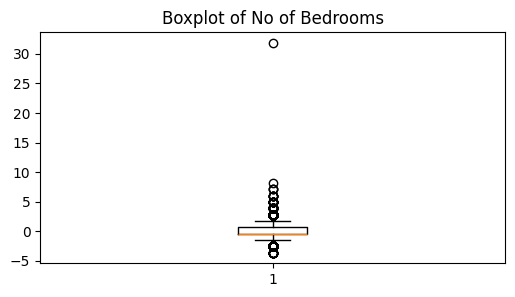

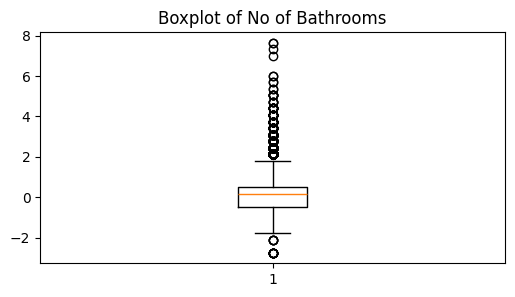

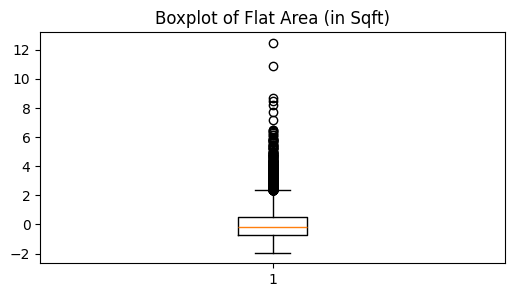

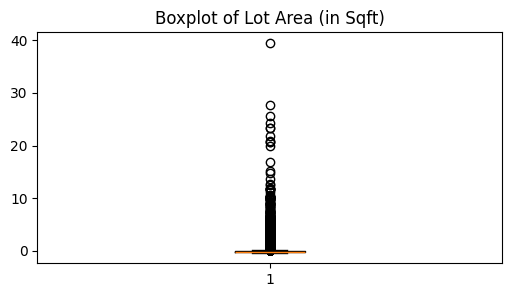

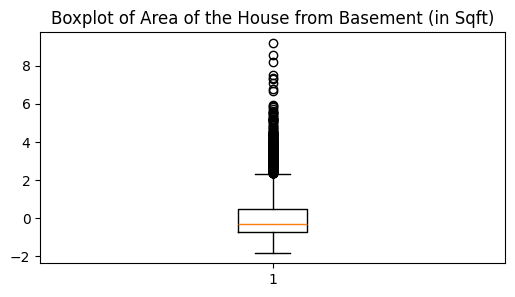

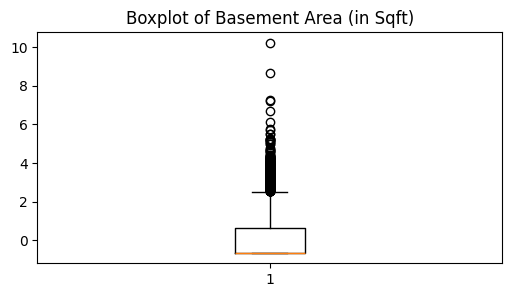

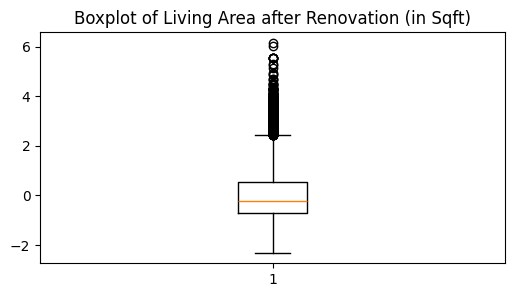

In [31]:
# boxplots to see outliers

import matplotlib.pyplot as plt

for col in cols_to_clean:
    plt.figure(figsize=(6,3))
    plt.boxplot(X[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [32]:
# Function to remove outliers using the IQR method
def remove_outliers(df, columns):
    df_cleaned = df.copy()  # Make a copy so original df is not changed
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Keep only rows within the bounds
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]

    return df_cleaned


In [33]:
# Function to remove outliers using the IQR method
# Apply the function to X
X_cleaned = remove_outliers(X, cols_to_clean)

# Align y (target variable) with cleaned features
y = y.loc[X_cleaned.index]

# Check shapes to see how many rows were removed
print(f"Original X shape: {X.shape}")
print(f"Cleaned X shape: {X_cleaned.shape}")


Original X shape: (21609, 19)
Cleaned X shape: (17134, 19)


In [34]:
print(X.shape)         # Original features
print(X_cleaned.shape) # After removing outliers


(21609, 19)
(17134, 19)


In [35]:
print(X_cleaned.shape[0])
print(y.shape[0])


17134
17134


**Train-Test Split**
* Set aside the SalePrice column as the target variable.
* Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.

In [36]:
from sklearn.model_selection import train_test_split


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,   # features
    y,           # target
    test_size=0.2,  # 20% data for testing
    random_state=42 # fixed seed for reproducibility
)


In [38]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (13707, 19)
y_train shape: (13707,)
X_test shape: (3427, 19)
y_test shape: (3427,)
